# Temperature model - Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-04

# Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import re
import math

# Import Database

In [2]:
database = 'Processability and Product Properties Data Library of scl-PHAs_2nd upload_V03.xlsx'

# Create DataFrames for each type of properties

In [3]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(database, sheet_name='Physchem_properties')

# Thermal properties DataFrame
df_therm = pd.read_excel(database, sheet_name='Thermal_properties')

# Process Physicochemical properties DataFrame

In [4]:
# Check for columns names and null values
df_physicochem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Study_id                                 598 non-null    int64  
 1   Instance                                 598 non-null    int64  
 2   Monomer_A                                593 non-null    object 
 3   Monomer_B                                585 non-null    object 
 4   HB_ratio (mol%)                          595 non-null    float64
 5   HV_ratio (mol%)                          595 non-null    float64
 6   Mw_PHBV                                  346 non-null    float64
 7   Mn_PHBV                                  144 non-null    float64
 8   Density                                  110 non-null    float64
 9   Density_units                            110 non-null    object 
 10  PDI                                      179 non-n

In [5]:
df_therm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Study_id           598 non-null    int64  
 1   Instance           598 non-null    int64  
 2   Tg1                257 non-null    float64
 3   Tg2                20 non-null     float64
 4   Tc1                319 non-null    float64
 5   Tc2                5 non-null      float64
 6   Tmc                49 non-null     float64
 7   Tm1                525 non-null    float64
 8   Tm2                192 non-null    float64
 9   Td5                202 non-null    float64
 10  Tdeg               101 non-null    float64
 11  Temperature_units  565 non-null    object 
 12  DHm1               341 non-null    float64
 13  DHm2               38 non-null     float64
 14  DHc1               179 non-null    float64
 15  DHc2               7 non-null      float64
 16  Enthaply_units     333 non

## Merge thermal properties

In [6]:
def add_max_mean_columns(df, col1, col2, prefix):
    """
    Creates {prefix}_mean and {prefix}_max from col1/col2:
    - Both exist: mean / max of the two
    - Only one exists: that value (for both new columns)
    - Neither exists: NaN
    """
    df[f"{prefix}_mean"] = df[[col1, col2]].mean(axis=1, skipna=True)
    df[f"{prefix}_max"] = df[[col1, col2]].max(axis=1, skipna=True)
    return df


# ---- Usage ----
df_therm = add_max_mean_columns(df_therm, "Tm1", "Tm2", "tm")
df_therm = add_max_mean_columns(df_therm, "Tc1", "Tc2", "tc")

# Quick check
print(df_therm[["Tm1", "Tm2", "tm_mean", "tm_max", "Tc1", "Tc2", "tc_mean", "tc_max"]].head(10))
print("\nNon-null counts:")
print(df_therm[["tm_mean", "tm_max", "tc_mean", "tc_max"]].notna().sum())

      Tm1  Tm2  tm_mean  tm_max    Tc1  Tc2  tc_mean  tc_max
0  175.00  NaN   175.00  175.00    NaN  NaN      NaN     NaN
1  175.00  NaN   175.00  175.00    NaN  NaN      NaN     NaN
2  178.00  NaN   178.00  178.00    NaN  NaN      NaN     NaN
3  134.00  NaN   134.00  134.00    NaN  NaN      NaN     NaN
4  150.00  NaN   150.00  150.00    NaN  NaN      NaN     NaN
5  175.00  NaN   175.00  175.00  54.00  NaN    54.00   54.00
6  163.30  NaN   163.30  163.30  91.54  NaN    91.54   91.54
7  112.27  NaN   112.27  112.27  58.37  NaN    58.37   58.37
8  169.00  NaN   169.00  169.00    NaN  NaN      NaN     NaN
9  170.00  NaN   170.00  170.00    NaN  NaN      NaN     NaN

Non-null counts:
tm_mean    528
tm_max     528
tc_mean    320
tc_max     320
dtype: int64


In [7]:
# Process Mw, Mn and PDI columns
# PDI = Mw/Mn

mask_Mw = (
    df_physicochem['Mw_PHBV'].isna() &
    df_physicochem['Mn_PHBV'].notna() &
    df_physicochem['PDI'].notna()
)

mask_Mn = (
    df_physicochem['Mn_PHBV'].isna() &
    df_physicochem['Mw_PHBV'].notna() &
    df_physicochem['PDI'].notna()
)

mask_PDI = (
    df_physicochem['PDI'].isna() &
    df_physicochem['Mw_PHBV'].notna() &
    df_physicochem['Mn_PHBV'].notna()
)


df_physicochem.loc[mask_Mw, 'Mw_PHBV'] = (
    df_physicochem.loc[mask_Mw, 'PDI'] * df_physicochem.loc[mask_Mw, 'Mn_PHBV']
)

df_physicochem.loc[mask_Mn, 'Mn_PHBV'] = (
    df_physicochem.loc[mask_Mn, 'Mw_PHBV'] / df_physicochem.loc[mask_Mn, 'PDI']
)

df_physicochem.loc[mask_PDI, 'PDI'] = (
    df_physicochem.loc[mask_PDI, 'Mw_PHBV'] / df_physicochem.loc[mask_PDI, 'Mn_PHBV']
)

In [8]:
# Categorical columns to fill with 'not_applicable'
categorical_cols = ['Additive1_type', 'Additive2_type']

# Numerical columns to fill with 0
numeric_cols = ['Additive1_percentage (wt%)', 'Additive2_percentage (wt%)']

# Fill categorical columns
for col in categorical_cols:
    df_physicochem[col] = df_physicochem[col].fillna('no_additive').astype(str)

# Fill numerical columns
for col in numeric_cols:
    df_physicochem[col] = df_physicochem[col].fillna(0)

## Plot distributions of thermal properties

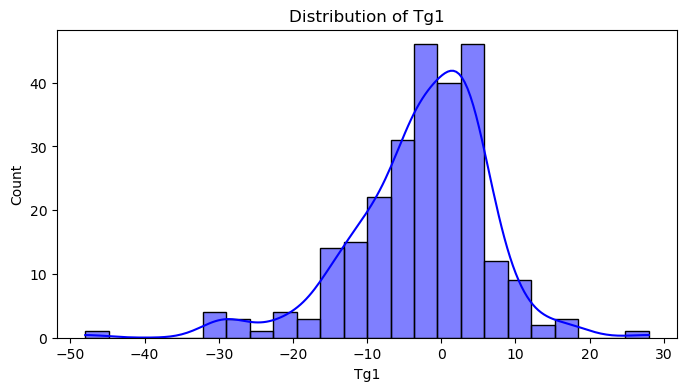

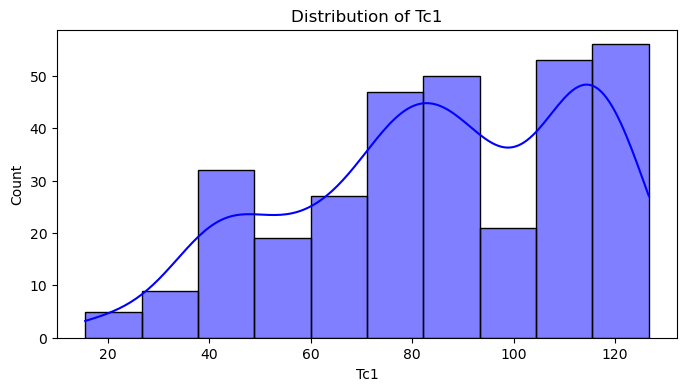

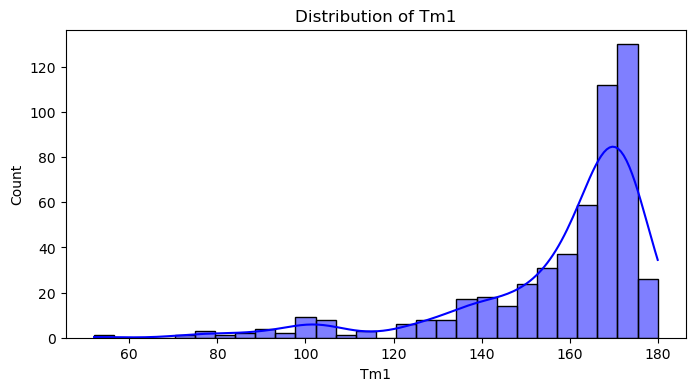

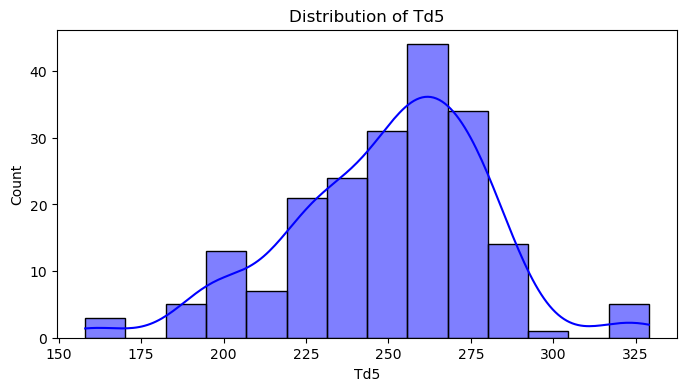

In [9]:
therm_col = ['Tg1', 'Tc1', 'Tm1', 'Td5']

for col in therm_col:
    if pd.api.types.is_numeric_dtype(df_therm[col]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df_therm[col], kde=True, color='blue')
        plt.title(f'Distribution of {col}')
    else:
        # Count number of unique categories for dynamic figure height
        num_categories = df_therm[col].nunique()
        fig_height = max(6, num_categories * 0.25)

        plt.figure(figsize=(10, fig_height))  # Wider and taller figure
        order = df_therm[col].value_counts().index  # Sort by frequency
        sns.countplot(y=col, data=df_therm, order=order, color='green')

        plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()

    plt.show()

# Merge

In [10]:
# Create merged Dataset
df_merged_fnl = pd.concat([df_physicochem, df_therm.drop(columns=['Study_id', 'Instance'])], axis=1)

In [11]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

## Fix typos, excl. special characters

In [12]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val

In [13]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,monomer_a,monomer_b,hb_ratio_mol,hv_ratio_mol,mw_phbv,mn_phbv,density,density_units,...,dhm1,dhm2,dhc1,dhc2,enthaply_units,crystallinity,tm_mean,tm_max,tc_mean,tc_max
0,1,1,3HB,NaN,100.0,0.0,1623000.0,1.345000e+06,NaN,NaN,...,58.0,NaN,NaN,NaN,J/g,NaN,175.0,175.0,NaN,NaN
1,2,1,3HB,NaN,100.0,0.0,166000.0,6.384615e+04,NaN,NaN,...,22.0,NaN,NaN,NaN,cal/g,NaN,175.0,175.0,NaN,NaN
2,3,1,3HB,NaN,100.0,0.0,3240000.0,1.940120e+06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,178.0,178.0,NaN,NaN
3,3,2,3HB,3HV,37.0,63.0,1700000.0,7.623318e+05,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,134.0,134.0,NaN,NaN
4,3,3,3HB,3HV,22.0,78.0,1830000.0,9.734043e+05,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,150.0,150.0,NaN,NaN


In [14]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [15]:
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'density', 'density_units', 'pdi',
       'additive1', 'additive1_type', 'additive1_name',
       'additive1_percentage_wt', 'additive2', 'additive2_type',
       'additive2_name', 'additive2_percentage_wt',
       'final_formulation_phbv_percentage_wt', 'unnamed_20', 'row_no', 'tg1',
       'tg2', 'tc1', 'tc2', 'tmc', 'tm1', 'tm2', 'td5', 'tdeg',
       'temperature_units', 'dhm1', 'dhm2', 'dhc1', 'dhc2', 'enthaply_units',
       'crystallinity', 'tm_mean', 'tm_max', 'tc_mean', 'tc_max'],
      dtype='object')

In [16]:
df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0

df_clean['additive_1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive_2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive_1'] == 'no', 'additive1_type'] = 'no_additive'
df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'no_additive'

## Drop features with more than 30% missing values

In [17]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.70]
df_clean.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio_mol',
       'hv_ratio_mol', 'mw_phbv', 'mn_phbv', 'pdi', 'additive1',
       'additive1_type', 'additive1_name', 'additive1_percentage_wt',
       'additive2', 'additive2_type', 'additive2_percentage_wt',
       'final_formulation_phbv_percentage_wt', 'row_no', 'tg1', 'tc1', 'tm1',
       'tm2', 'td5', 'temperature_units', 'dhm1', 'enthaply_units',
       'crystallinity', 'tm_mean', 'tm_max', 'tc_mean', 'tc_max', 'additive_1',
       'additive_2'],
      dtype='object')

## Feature engineering

In [18]:
df_clean['additive1_type'].value_counts()

additive1_type
no_additive                                 243
reinforcment_and_stiffening_modifiers       188
plasticizers_and_flexibility_enhancers      133
biofunctional_and_enviromental_additives     18
nucleating_agent                             16
Name: count, dtype: int64

In [19]:
df_clean['additive2_type'].value_counts()

additive2_type
no_additive                                 545
reinforcment_and_stiffening_modifiers        31
plasticizers_and_flexibility_enhancers       16
biofunctional_and_enviromental_additives      6
Name: count, dtype: int64

## Feature selection

In [20]:
# Select Features and Target
features = ['hb_ratio_mol', 'hv_ratio_mol', 'mw_phbv',
            'mn_phbv', 'pdi', 'additive1_type', 'additive1_percentage_wt', 'additive2_type',
            'additive2_percentage_wt',  'tg1', 'tc1','tm1', 'tm2', 'td5', 'dhm1', 'crystallinity','tm_mean', 'tm_max', 'tc_mean', 'tc_max'
           ]

In [21]:
df_new = df_clean[features]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hb_ratio_mol             595 non-null    float64
 1   hv_ratio_mol             595 non-null    float64
 2   mw_phbv                  381 non-null    float64
 3   mn_phbv                  226 non-null    float64
 4   pdi                      222 non-null    float64
 5   additive1_type           598 non-null    object 
 6   additive1_percentage_wt  598 non-null    float64
 7   additive2_type           598 non-null    object 
 8   additive2_percentage_wt  598 non-null    float64
 9   tg1                      257 non-null    float64
 10  tc1                      319 non-null    float64
 11  tm1                      525 non-null    float64
 12  tm2                      192 non-null    float64
 13  td5                      202 non-null    float64
 14  dhm1                     3

## Save

In [22]:
# Download United Dataset
df_new.to_csv('sclPHA_data_new_ext.csv', index=False)